In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/googleplaystore.csv")

In [6]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
df.shape

(10841, 13)

In [8]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [10]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [11]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [12]:
df.duplicated().sum()

np.int64(483)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(10358, 13)

In [19]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

In [20]:
df["Rating"].isnull().sum()

np.int64(0)

In [21]:
df.dropna(inplace=True)

In [22]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [23]:
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = pd.to_numeric(df["Installs"])

In [24]:
df["Installs"].head()

,Installs
0,10000
1,500000
2,5000000
3,50000000
4,100000


In [25]:
df["Installs"].head()

,Installs
0,10000
1,500000
2,5000000
3,50000000
4,100000


In [26]:
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"])

In [27]:
df["Price"].head()

,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [28]:
df["Reviews"] = pd.to_numeric(df["Reviews"])

In [29]:
df["Reviews"].dtype

dtype('float64')

In [30]:
df["Size"].unique()[:20]

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '5.5M', '17M', '39M', '31M',
       '4.2M', '7.0M'], dtype=object)

In [31]:
df["Size"].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '5.5M', '17M', '39M', '31M',
       '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M', '5.2M',
       '11M', '24M', 'Varies with device', '9.4M', '15M', '10M', '1.2M',
       '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k', '3.6M',
       '5.7M', '8.6M', '2.4M', '27M', '2.7M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [32]:
df = df[df["Size"] != "Varies with device"]

In [33]:
df["Size"] = df["Size"].str.replace("M", "", regex=False)
df["Size"] = df["Size"].str.replace("k", "", regex=False)
df["Size"] = pd.to_numeric(df["Size"], errors="coerce")

In [34]:
df["Size"].head()

,Size
0,19.0
1,14.0
2,8.7
3,25.0
4,2.8


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8821 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8821 non-null   object 
 1   Category        8821 non-null   object 
 2   Rating          8821 non-null   float64
 3   Reviews         8821 non-null   float64
 4   Size            8821 non-null   float64
 5   Installs        8821 non-null   int64  
 6   Type            8821 non-null   object 
 7   Price           8821 non-null   float64
 8   Content Rating  8821 non-null   object 
 9   Genres          8821 non-null   object 
 10  Last Updated    8821 non-null   object 
 11  Current Ver     8821 non-null   object 
 12  Android Ver     8821 non-null   object 
dtypes: float64(4), int64(1), object(8)
memory usage: 964.8+ KB


In [36]:
category_count = df["Category"].value_counts()

category_count.head(10)

,count
Category,
FAMILY,1803
GAME,1000
TOOLS,737
MEDICAL,380
BUSINESS,379
PERSONALIZATION,352
LIFESTYLE,338
FINANCE,304
PRODUCTIVITY,299


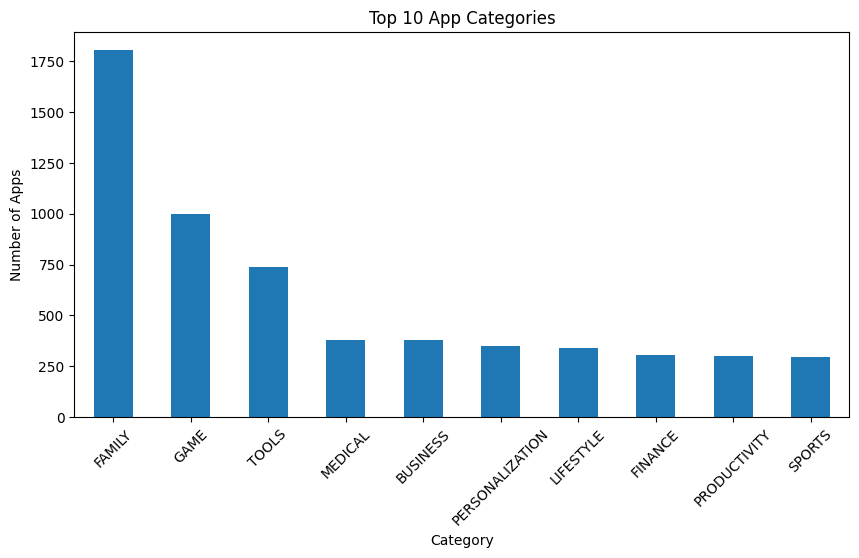

In [37]:
plt.figure(figsize=(10,5))
category_count.head(10).plot(kind="bar")

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.show()

In [38]:
type_count = df["Type"].value_counts()

type_count

,count
Type,
Free,8133
Paid,688


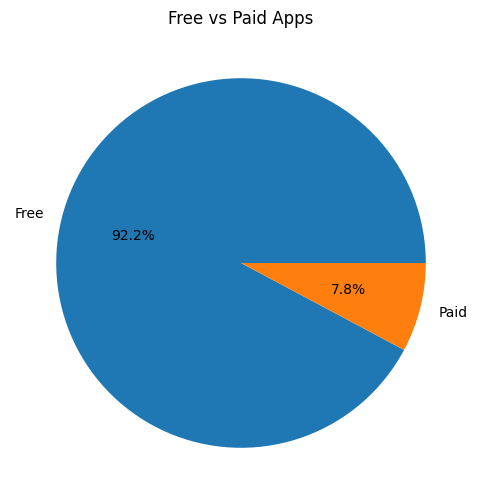

In [39]:
plt.figure(figsize=(6,6))

type_count.plot(kind="pie", autopct="%1.1f%%")

plt.title("Free vs Paid Apps")

plt.ylabel("")

plt.show()

In [40]:
avg_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)

avg_rating.head(10)

,Rating
Category,
EVENTS,4.419298
EDUCATION,4.379167
ART_AND_DESIGN,4.377049
PARENTING,4.338889
PERSONALIZATION,4.318750
BOOKS_AND_REFERENCE,4.315897
BEAUTY,4.293617
GAME,4.267100
SOCIAL,4.266995


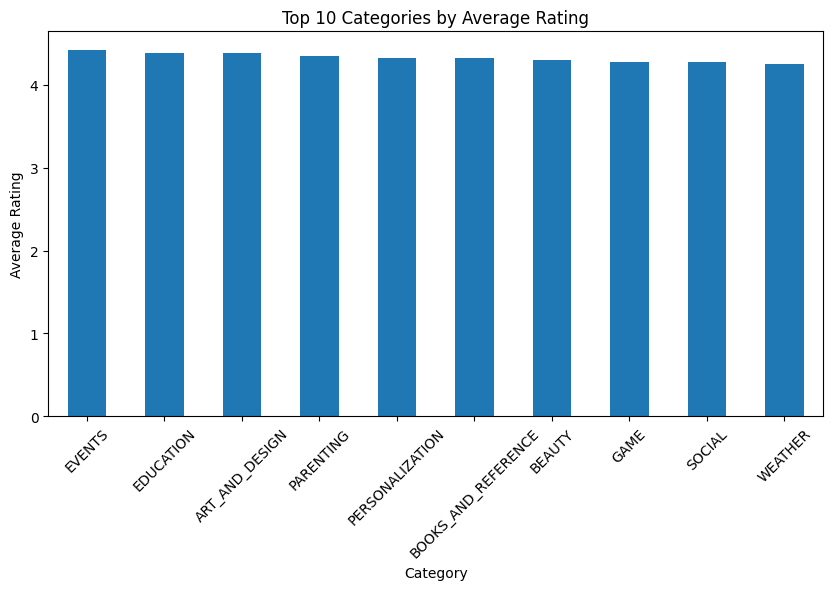

In [41]:
plt.figure(figsize=(10,5))

avg_rating.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Average Rating")

plt.xlabel("Category")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [42]:
top_installs = df.groupby("Category")["Installs"].sum().sort_values(ascending=False)

top_installs.head(10)

,Installs
Category,
GAME,26802564253
FAMILY,6697162325
TOOLS,3526594805
COMMUNICATION,3336943051
NEWS_AND_MAGAZINES,3215005650
PRODUCTIVITY,2711312744
PHOTOGRAPHY,2390897655
SHOPPING,1312748785
SPORTS,1062449498


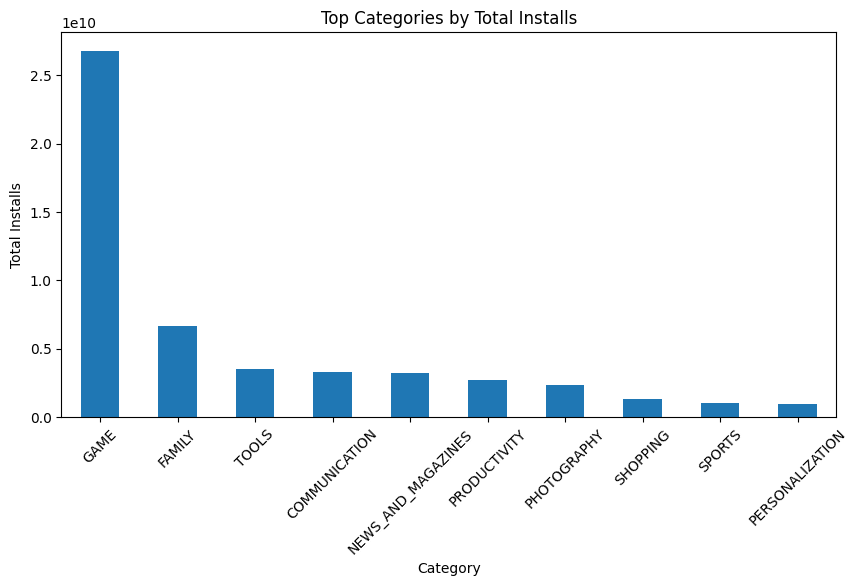

In [43]:
plt.figure(figsize=(10,5))

top_installs.head(10).plot(kind="bar")

plt.title("Top Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")

plt.xticks(rotation=45)

plt.show()

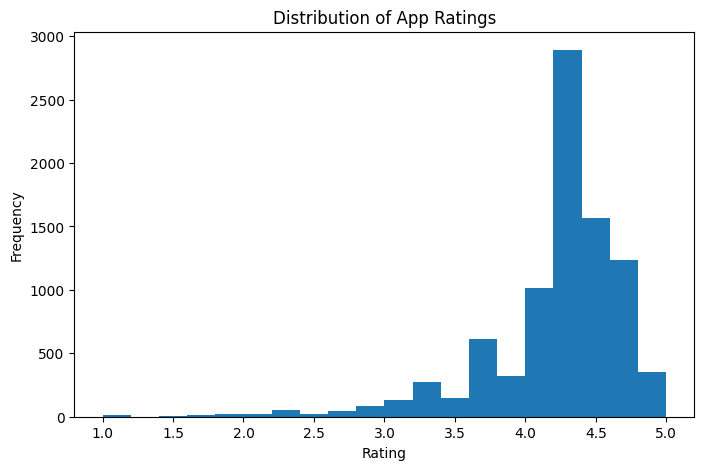

In [44]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=20)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

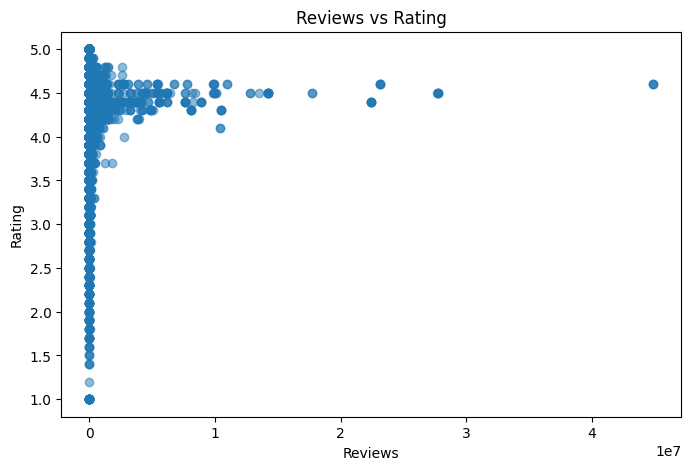

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(df["Reviews"], df["Rating"], alpha=0.5)

plt.title("Reviews vs Rating")
plt.xlabel("Reviews")
plt.ylabel("Rating")

plt.show()

In [46]:
content = df["Content Rating"].value_counts()

content

,count
Content Rating,
Everyone,7185
Teen,951
Mature 17+,368
Everyone 10+,313
Adults only 18+,2
Unrated,2


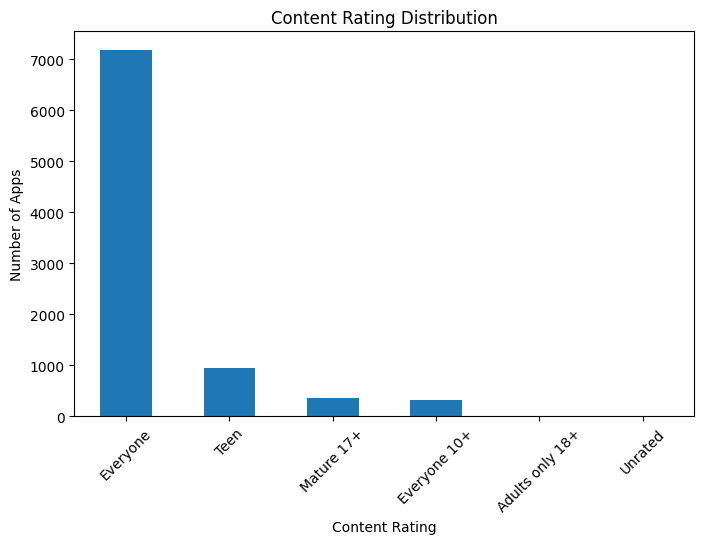

In [47]:
plt.figure(figsize=(8,5))

content.plot(kind="bar")

plt.title("Content Rating Distribution")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.show()

In [48]:
top_apps = df.nlargest(10, "Installs")[["App", "Installs"]]

top_apps

,App,Installs
1654,Subway Surfers,1000000000
1700,Subway Surfers,1000000000
1750,Subway Surfers,1000000000
1872,Subway Surfers,1000000000
3736,Google News,1000000000
3816,Google News,1000000000
3896,Subway Surfers,1000000000
9844,Google News,1000000000
347,imo free video calls and chat,500000000
378,UC Browser - Fast Download Private & Secure,500000000


In [49]:
genres = df["Genres"].value_counts()

genres.head(10)

,count
Genres,
Tools,737
Entertainment,516
Education,482
Medical,380
Business,379
Personalization,352
Lifestyle,337
Action,323
Sports,309


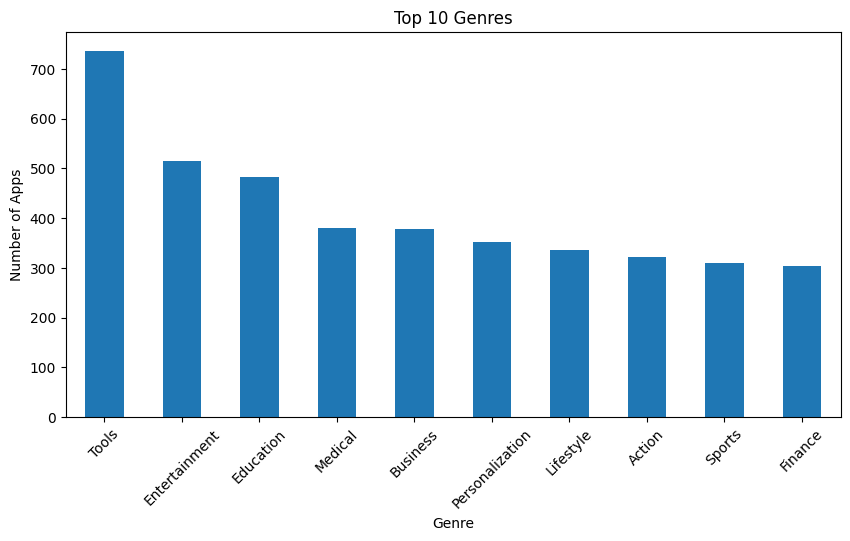

In [50]:
plt.figure(figsize=(10,5))

genres.head(10).plot(kind="bar")

plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.show()

In [51]:
corr = df[["Rating", "Reviews", "Installs", "Price", "Size"]].corr()

corr

,Rating,Reviews,Installs,Price,Size
Rating,1.000000,0.074033,0.047747,-0.019413,-0.018182
Reviews,0.074033,1.000000,0.633603,-0.009701,0.030865
Installs,0.047747,0.633603,1.000000,-0.010290,0.014910
Price,-0.019413,-0.009701,-0.010290,1.000000,0.014705
Size,-0.018182,0.030865,0.014910,0.014705,1.000000
